In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [19]:
import pandas as pd

df = pd.read_csv("data/raw/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [23]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [30]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df['loan_int_rate'].median()
)

In [32]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


In [43]:
# Target variable (Classification)
y_classification = df['loan_status']

# Features
X = df.drop('loan_status', axis=1)

print("Feature Shape:", X.shape)
print("Target Shape:", y_classification.shape)

Feature Shape: (32581, 11)
Target Shape: (32581,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (26064, 11)
Testing Data: (6517, 11)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [55]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8371950283872948
Precision: 0.7162162162162162
Recall: 0.4401384083044983
F1 Score: 0.5452207458208316

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      5072
           1       0.72      0.44      0.55      1445

    accuracy                           0.84      6517
   macro avg       0.79      0.70      0.72      6517
weighted avg       0.83      0.84      0.82      6517



In [57]:
cm_log = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:\n", cm_log)

Confusion Matrix:
 [[4820  252]
 [ 809  636]]


In [59]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [61]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9289550406628817
Precision: 0.9632075471698113
Recall: 0.7065743944636678
F1 Score: 0.8151696606786427

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.71      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.92      6517



In [63]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

Confusion Matrix:
 [[5033   39]
 [ 424 1021]]


In [70]:
default_prob = rf_model.predict_proba(X_test)[:, 1]

default_prob[:10]

array([0.08, 0.24, 0.23, 0.98, 0.97, 0.06, 0.02, 0.  , 0.04, 0.06])

In [125]:
def assign_risk(prob):
    if prob < 0.35:
        return "Low Risk"
    elif prob < 0.65:
        return "Medium Risk"
    else:
        return "High Risk"


risk_category = [assign_risk(p) for p in default_prob]

risk_category[:10]

['Low Risk',
 'Low Risk',
 'Low Risk',
 'High Risk',
 'High Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk',
 'Low Risk']

In [127]:
results = pd.DataFrame(X_test, columns=X.columns)

results['Actual_Status'] = y_test.values
results['Predicted_Status'] = y_pred_rf
results['Default_Probability'] = default_prob
results['Risk_Category'] = risk_category

results.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual_Status,Predicted_Status,Default_Probability,Risk_Category
0,-0.588935,-0.600204,0.226253,0.304473,-0.304780,-0.185463,0.063165,-0.207785,1.771713,-0.459881,-0.941409,0,0,0.08,Low Risk
1,-0.119626,-0.034150,0.924046,-1.175440,0.849923,0.674664,0.063165,1.387551,-0.097634,2.174477,1.031822,0,0,0.24,Low Risk
2,-0.276062,0.091640,-1.169333,1.291081,-0.882131,1.534792,1.013189,-0.005926,0.463170,-0.459881,-0.694755,0,0,0.23,Low Risk
3,-0.745371,-0.600267,0.924046,0.551125,-1.459482,-1.045591,0.063165,-0.005926,1.771713,-0.459881,-0.941409,1,1,0.98,High Risk
4,0.349683,-0.340762,0.924046,-0.682135,0.272572,2.394920,0.538177,1.729409,1.117442,-0.459881,0.045207,1,1,0.97,High Risk


In [129]:
confidence_score = abs(default_prob - 0.5) * 2

In [131]:
confidence_score = confidence_score * 100

In [133]:
results['Confidence (%)'] = confidence_score
results.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual_Status,Predicted_Status,Default_Probability,Risk_Category,Confidence (%)
0,-0.588935,-0.600204,0.226253,0.304473,-0.304780,-0.185463,0.063165,-0.207785,1.771713,-0.459881,-0.941409,0,0,0.08,Low Risk,84.0
1,-0.119626,-0.034150,0.924046,-1.175440,0.849923,0.674664,0.063165,1.387551,-0.097634,2.174477,1.031822,0,0,0.24,Low Risk,52.0
2,-0.276062,0.091640,-1.169333,1.291081,-0.882131,1.534792,1.013189,-0.005926,0.463170,-0.459881,-0.694755,0,0,0.23,Low Risk,54.0
3,-0.745371,-0.600267,0.924046,0.551125,-1.459482,-1.045591,0.063165,-0.005926,1.771713,-0.459881,-0.941409,1,1,0.98,High Risk,96.0
4,0.349683,-0.340762,0.924046,-0.682135,0.272572,2.394920,0.538177,1.729409,1.117442,-0.459881,0.045207,1,1,0.97,High Risk,94.0


In [135]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
8,loan_percent_income,0.233303
1,person_income,0.146597
7,loan_int_rate,0.111775
5,loan_grade,0.109982
2,person_home_ownership,0.099132
4,loan_intent,0.073431
6,loan_amnt,0.071472
3,person_emp_length,0.064553
0,person_age,0.044045
10,cb_person_cred_hist_length,0.034939


In [137]:
def risk_reason(row):
    reasons = []
    
    if row['loan_percent_income'] > 0.4:
        reasons.append("High loan compared to income")
        
    if row['loan_int_rate'] > 15:
        reasons.append("High interest rate")
        
    if row['person_income'] < 30000:
        reasons.append("Low income level")
        
    if len(reasons) == 0:
        return "Normal financial profile"
        
    return ", ".join(reasons)


results['Risk_Explanation'] = results.apply(risk_reason, axis=1)

results.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual_Status,Predicted_Status,Default_Probability,Risk_Category,Confidence (%),Risk_Explanation
0,-0.588935,-0.600204,0.226253,0.304473,-0.304780,-0.185463,0.063165,-0.207785,1.771713,-0.459881,-0.941409,0,0,0.08,Low Risk,84.0,"High loan compared to income, Low income level"
1,-0.119626,-0.034150,0.924046,-1.175440,0.849923,0.674664,0.063165,1.387551,-0.097634,2.174477,1.031822,0,0,0.24,Low Risk,52.0,Low income level
2,-0.276062,0.091640,-1.169333,1.291081,-0.882131,1.534792,1.013189,-0.005926,0.463170,-0.459881,-0.694755,0,0,0.23,Low Risk,54.0,"High loan compared to income, Low income level"
3,-0.745371,-0.600267,0.924046,0.551125,-1.459482,-1.045591,0.063165,-0.005926,1.771713,-0.459881,-0.941409,1,1,0.98,High Risk,96.0,"High loan compared to income, Low income level"
4,0.349683,-0.340762,0.924046,-0.682135,0.272572,2.394920,0.538177,1.729409,1.117442,-0.459881,0.045207,1,1,0.97,High Risk,94.0,"High loan compared to income, Low income level"


In [139]:
import pickle

with open("models/risk_classifier.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model saved successfully!")

Model saved successfully!


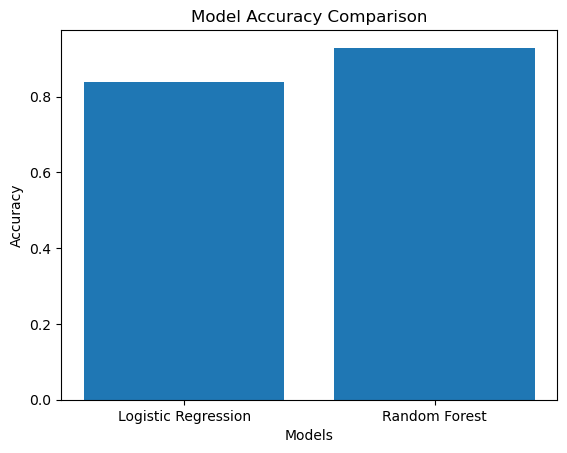

In [141]:
models = ['Logistic Regression', 'Random Forest']
accuracy = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

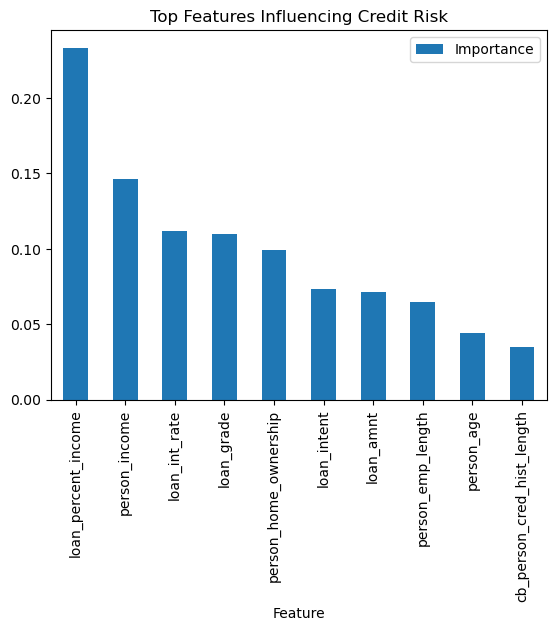

In [143]:
feature_importance.sort_values(by='Importance', ascending=False).head(10).plot(
    x='Feature', y='Importance', kind='bar'
)

plt.title("Top Features Influencing Credit Risk")
plt.show()

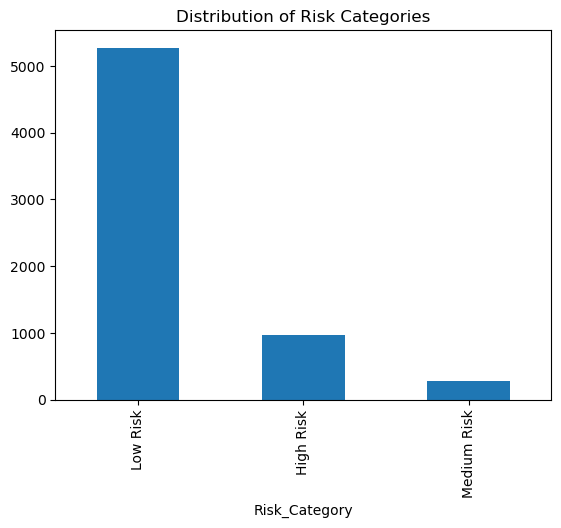

In [145]:
results['Risk_Category'].value_counts().plot(kind='bar')
plt.title("Distribution of Risk Categories")
plt.show()

In [147]:
sample = X_test[0:1]

prob = rf_model.predict_proba(sample)[:,1][0]

print("Default Probability:", prob)
print("Risk Category:", assign_risk(prob))

Default Probability: 0.08
Risk Category: Low Risk


In [149]:
def loan_decision(risk_category):
    
    if risk_category == "Low Risk":
        return "Approve Loan"
    
    elif risk_category == "Medium Risk":
        return "Manual Review Required"
    
    else:
        return "Reject Loan"

In [151]:
def predict_risk(input_data):

    input_df = pd.DataFrame([input_data])

    prob = rf_model.predict_proba(input_df)[:,1][0]

    risk = assign_risk(prob)

    confidence = abs(prob - 0.5) * 2 * 100

    decision = loan_decision(risk)

    print("Default Probability:", round(prob, 2))
    print("Risk Category:", risk)
    print("Confidence:", round(confidence, 2), "%")
    print("Recommended Decision:", decision)

In [153]:
demo_customer = {
    'person_age': 28,
    'person_income': 45000,
    'person_home_ownership': 1,
    'person_emp_length': 3,
    'loan_intent': 2,
    'loan_grade': 2,
    'loan_amnt': 20000,
    'loan_int_rate': 14,
    'loan_percent_income': 0.45,
    'cb_person_default_on_file': 0,
    'cb_person_cred_hist_length': 4
}

predict_risk(demo_customer)

Default Probability: 0.44
Risk Category: Medium Risk
Confidence: 12.0 %
Recommended Decision: Manual Review Required


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [155]:
demo_customer = {
    'person_age': 32,
    'person_income': 90000,              # High income
    'person_home_ownership': 1,          # Own or stable housing
    'person_emp_length': 8,              # Stable job
    'loan_intent': 2,
    'loan_grade': 1,                     # Better loan grade
    'loan_amnt': 10000,                  # Smaller loan
    'loan_int_rate': 9,                  # Lower interest rate
    'loan_percent_income': 0.10,         # Very low financial burden
    'cb_person_default_on_file': 0,      # No past default
    'cb_person_cred_hist_length': 10     # Long credit history
}

predict_risk(demo_customer)

Default Probability: 0.34
Risk Category: Low Risk
Confidence: 32.0 %
Recommended Decision: Approve Loan


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [157]:
demo_customer = {
    'person_age': 35,
    'person_income': 120000,         # Much higher income
    'person_home_ownership': 1,
    'person_emp_length': 10,
    'loan_intent': 2,
    'loan_grade': 0,                 # Best grade in encoding
    'loan_amnt': 5000,               # Small loan
    'loan_int_rate': 7,              # Low interest rate
    'loan_percent_income': 0.05,     # Very low burden
    'cb_person_default_on_file': 0,
    'cb_person_cred_hist_length': 12
}

predict_risk(demo_customer)

Default Probability: 0.31
Risk Category: Low Risk
Confidence: 38.0 %
Recommended Decision: Approve Loan


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
